# Comparaison des filtres analogiques

In [1]:
from numpy import pi, log10
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
plt.style.use('../../src/signal.mplstyle')

In [2]:
# Caractéristiques des filtres
N, fc = 3, 1
rp, rs = 3, 30

# Conception des filtres
coefs = [
    ["Butterworth",   signal.butter(N, fc*2*pi, 'low', analog=True)],
    ["Bessel",        signal.bessel(N, fc*2*pi, 'low', analog=True)],
    ["Tchebychev I",  signal.cheby1(N, rp, fc*2*pi, 'low', analog=True)],
    ["Tchebychev II", signal.cheby2(N, rs, fc*2*pi, 'low', analog=True)],
    ["Elliptique",    signal.ellip(N, rp, rs, fc*2*pi, 'low', analog=True)],
]

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_11849/3663829692.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mathrm{Re}(s)$')
/tmp/ipykernel_11849/3663829692.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathrm{Im}(s)$')
/tmp/ipykernel_11849/3663829692.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


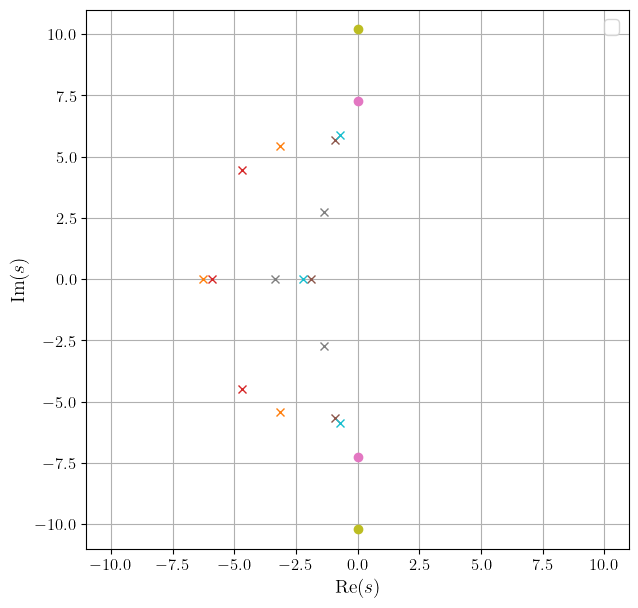

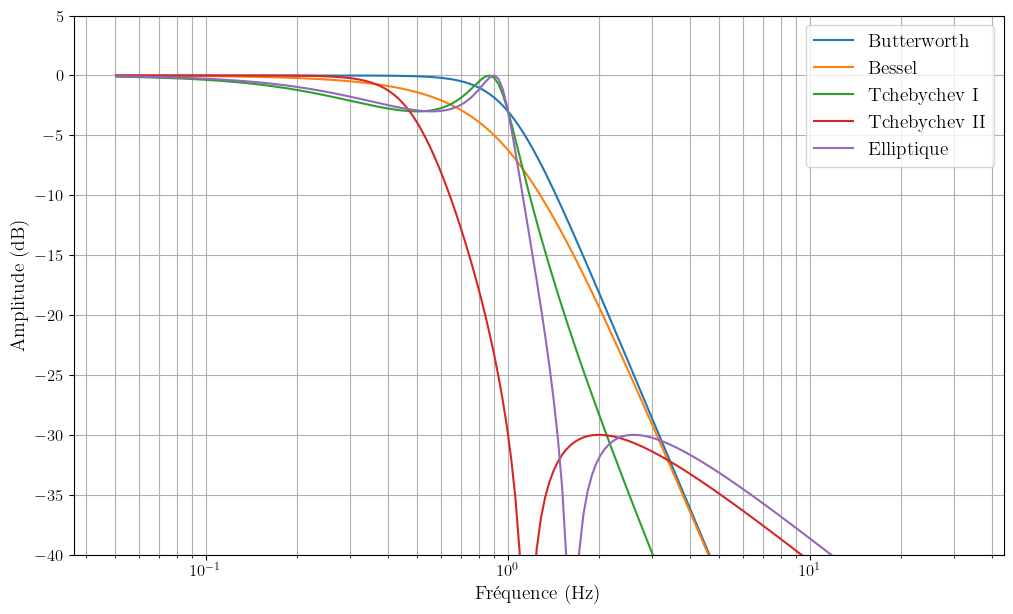

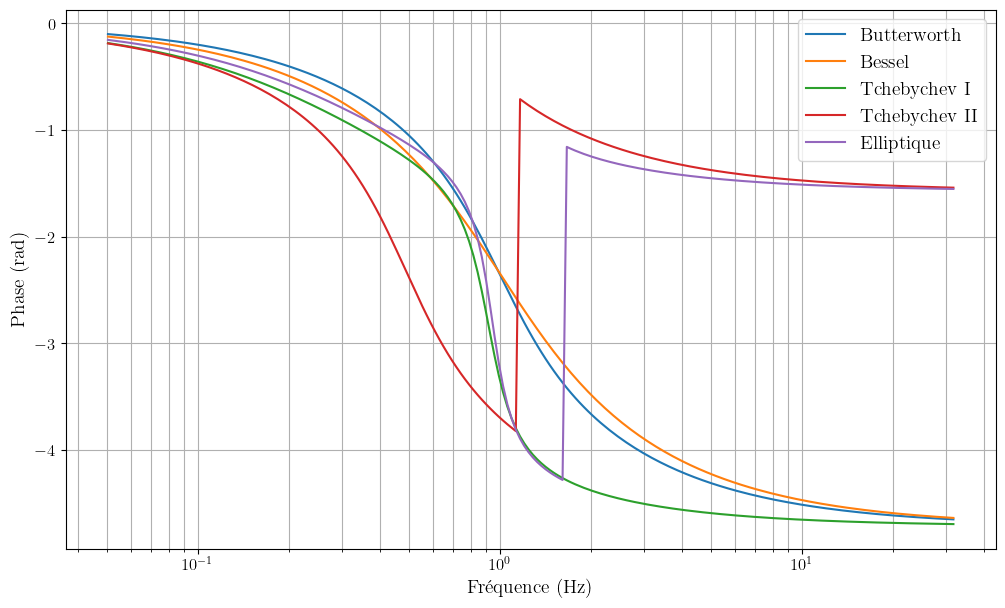

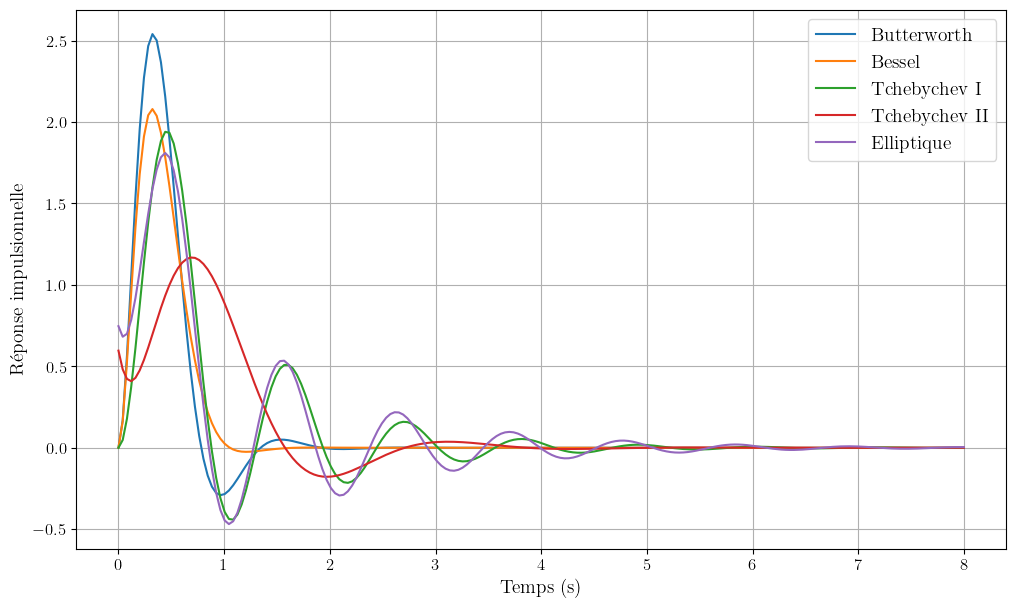

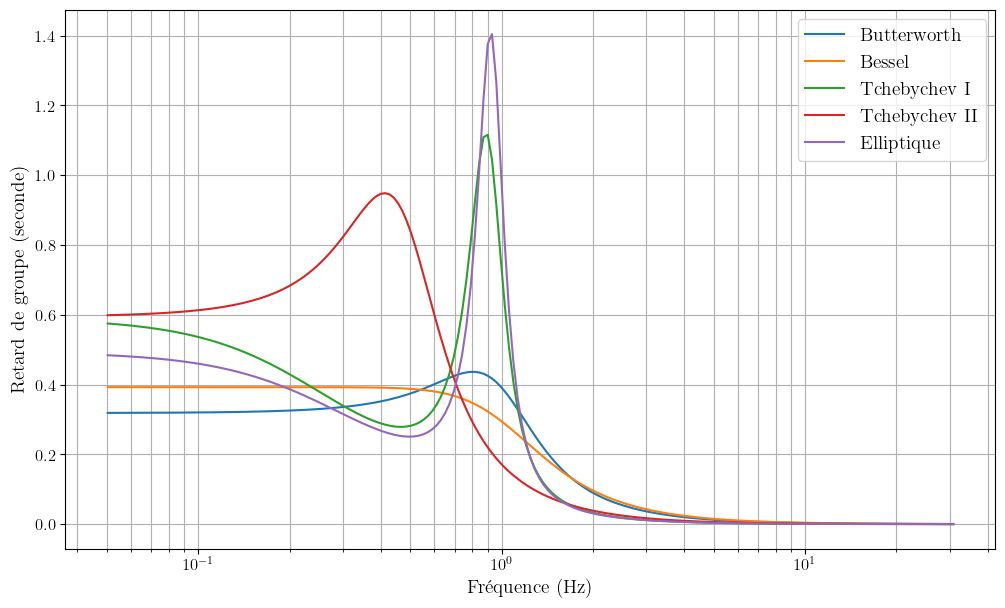

In [3]:
# Caractéristiques de l'affichage
M, N = 12, 7
w = np.logspace(-.5,2.3,200)

# Diagramme pôle-zéro
plt.figure(figsize=(N,N))
for title, c in coefs:
    b, a = c
    z, p, k = signal.tf2zpk(b, a)
    plt.plot(np.real(z), np.imag(z), "o")
    plt.plot(np.real(p), np.imag(p), "x")
plt.xlabel('$\mathrm{Re}(s)$')
plt.ylabel('$\mathrm{Im}(s)$')
plt.grid(which='minor', axis='both')
plt.xlim([-11, 11])
plt.ylim([-11, 11])
plt.legend()
# plt.savefig("fana-zp.svg")
plt.show()

# Gain
plt.figure(figsize=(M,N))
for title, c in coefs:
    b, a = c
    w, h = signal.freqs(b, a, w)
    plt.semilogx(w/(2*pi), 20*log10(abs(h)), label=title)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude (dB)')
plt.grid(which='minor', axis='both')
plt.ylim([-40, 5])
plt.legend()
plt.savefig("fana-gain.svg")
plt.savefig("fana-gain.png")
plt.show()

# Phase
plt.figure(figsize=(M,N))
for title, c in coefs:
    b, a = c
    w, h = signal.freqs(b, a, w)
    plt.semilogx(w/(2*pi), np.unwrap(np.angle(h)), label=title)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Phase (rad)')
plt.grid(which='minor', axis='both')
plt.legend()
plt.savefig("fana-phase.svg")
plt.savefig("fana-phase.png")
plt.show()

# Réponse impulsionnelle
plt.figure(figsize=(M,N))
for title, c in coefs:
    b, a = c
    t, y = signal.impulse((b, a), T=np.linspace(0, 8, 200))
    plt.plot(t, y, label=title)
plt.xlabel('Temps (s)')
plt.ylabel('Réponse impulsionnelle')
plt.grid(which='minor', axis='both')
plt.legend()
plt.savefig("fana-impulse.svg")
plt.savefig("fana-impulse.png")
plt.show()

# Retard de groupe
w = np.logspace(-.5,2.3,200)
plt.figure(figsize=(M,N))
for title, c in coefs:
    
    # Réponse fréquentielle
    b, a = c
    w, h = signal.freqs(b, a, w)
    
    # Retard de groupe
    # Pas de 2*pi car on travaille en pulsation
    # np.diff(w) au dénumérateur correspond à la largeur des échantillons et permet de calculer la différence finie
    gd = - np.diff(np.unwrap(np.angle(h))) / np.diff(w)
    
    # Remplace les variables aberrantes par la moyenne des échantillons à gauche et droite
    idx = np.where(gd<-.2)
    mean_gd = (gd[:-2]+gd[2:])/2
    gd[idx] = mean_gd[np.array(idx)-1]
    
    # Affichage
    plt.semilogx(w[:-1]/(2*pi), gd, label=title)
    
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Retard de groupe (seconde)')
plt.grid(which='minor', axis='both')
plt.legend()
plt.savefig("fana-gd.svg")
plt.savefig("fana-gd.png")
plt.show()
